# Financial Fraud Detection & Transaction Risk Analytics

## 1. Project Overview

Financial transaction fraud is a highly imbalanced classification problem in which
fraudulent transactions represent only a small fraction of total transactions.

This project develops a data-driven fraud detection pipeline to identify potentially
fraudulent transactions and analyze transaction-level risk.

The project combines exploratory data analysis, statistical analysis, feature
preprocessing, supervised machine learning, and anomaly detection techniques.

## 2. Problem Statement

Given a financial transaction, determine whether it is:

- **Legitimate (Class 0)**
- **Fraudulent (Class 1)**

The primary challenge is detecting the minority fraud class while minimizing
false positives on legitimate transactions.

## 3. Objectives

- Understand the structure and characteristics of transaction data
- Perform exploratory data analysis (EDA)
- Analyze the class imbalance problem
- Investigate relationships between transaction features and fraud
- Prepare features for machine learning
- Develop and compare fraud detection models
- Evaluate models using precision, recall, F1-score, ROC-AUC and PR-AUC
- Generate transaction-level risk scores
- Analyze the practical trade-off between fraud detection and false alarms

## 4. Methodology

The project follows the following workflow:

Dataset
→ Data Understanding
→ Data Quality Analysis
→ Exploratory Data Analysis
→ Feature Analysis
→ Data Preprocessing
→ Model Development
→ Model Evaluation
→ Risk Scoring
→ Insights & Conclusions

## 5. Machine Learning Approach

The project will investigate both supervised classification and anomaly detection.

### Supervised Learning
- Logistic Regression
- Random Forest Classifier

### Anomaly Detection
- Isolation Forest

### Evaluation

Because fraudulent transactions are highly underrepresented, accuracy alone is
not an appropriate measure of model performance.

The analysis will therefore focus on:

- Precision
- Recall
- F1-score
- ROC-AUC
- Precision-Recall AUC (PR-AUC)
- Confusion Matrix

## 6. Exploratory Data Analysis and Feature Analysis

Exploratory Data Analysis (EDA) is performed to understand the statistical properties of the transaction data and identify patterns associated with fraudulent transactions.

The analysis focuses on:

- Dataset structure and data quality
- Class distribution and fraud-rate imbalance
- Transaction amount distribution
- Log-transformed transaction amounts
- Differences in feature distributions between legitimate and fraudulent transactions
- Correlation between transaction features and the fraud target
- Identification of features that exhibit strong relationships with fraud

Because the dataset is highly imbalanced, both absolute transaction counts and class-specific statistics are considered when interpreting the results.

Feature analysis is used to develop an understanding of potentially discriminative variables before proceeding to feature preprocessing and machine-learning model development.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nBasic Information:")
df.info()

Dataset Shape: (284807, 31)

Missing Values:
0

Duplicate Rows:
1081

Data Types:
float64    30
int64       1
Name: count, dtype: int64

Basic Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 no

In [5]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

print("Total duplicate rows:", duplicate_rows.shape[0])

print("\nClass distribution among duplicate rows:")
print(duplicate_rows["Class"].value_counts())

print("\nDuplicate groups with conflicting Class labels:")
conflicting_duplicates = (
    duplicate_rows
    .groupby(list(df.columns[:-1]))["Class"]
    .nunique()
)

print((conflicting_duplicates > 1).sum())

Total duplicate rows: 1854

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64

Duplicate groups with conflicting Class labels:
0


In [6]:
class_counts = df["Class"].value_counts().sort_index()

print("Transaction Class Distribution:")
print(class_counts)

fraud_count = class_counts[1]
legitimate_count = class_counts[0]

fraud_rate = fraud_count / len(df) * 100

print(f"\nLegitimate transactions: {legitimate_count:,}")
print(f"Fraudulent transactions: {fraud_count:,}")
print(f"Fraud rate: {fraud_rate:.4f}%")

Transaction Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Legitimate transactions: 284,315
Fraudulent transactions: 492
Fraud rate: 0.1727%


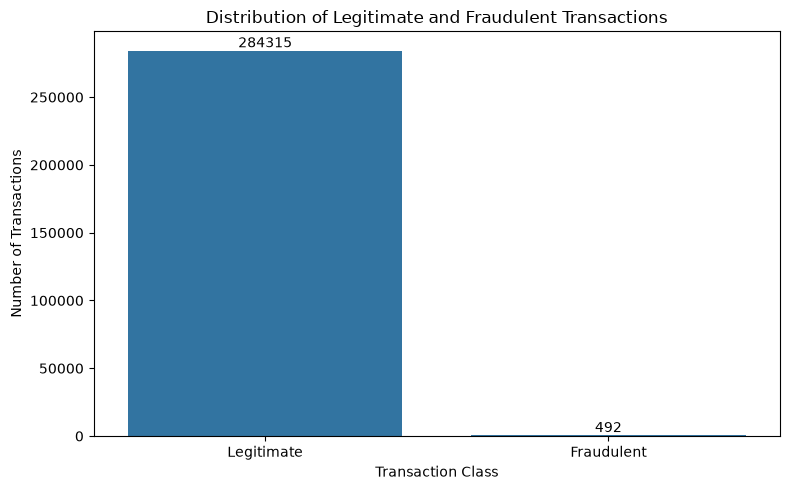

In [7]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

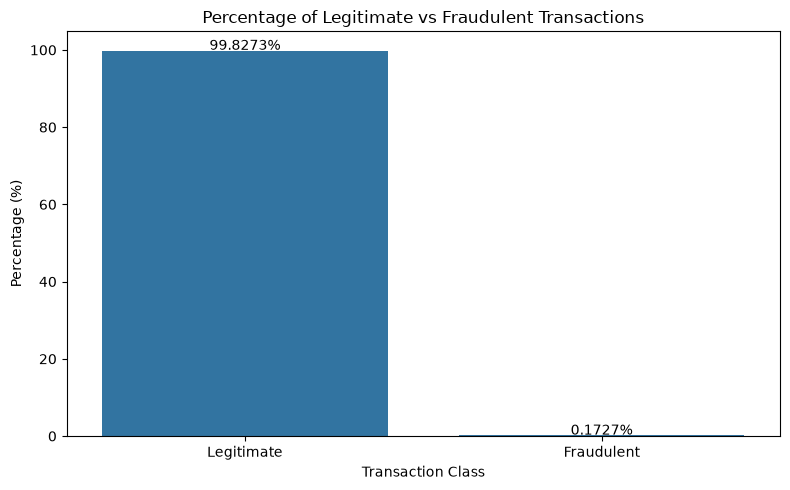

In [8]:
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=["Legitimate", "Fraudulent"],
    y=class_percentages.values
)

plt.title("Percentage of Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Percentage (%)")

for i, value in enumerate(class_percentages.values):
    ax.text(i, value + 0.2, f"{value:.4f}%", ha="center")

plt.tight_layout()
plt.show()

In [9]:
amount_stats = df.groupby("Class")["Amount"].describe()

amount_stats.index = ["Legitimate", "Fraudulent"]

amount_stats

,count,mean,std,min,25%,50%,75%,max
Legitimate,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
Fraudulent,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


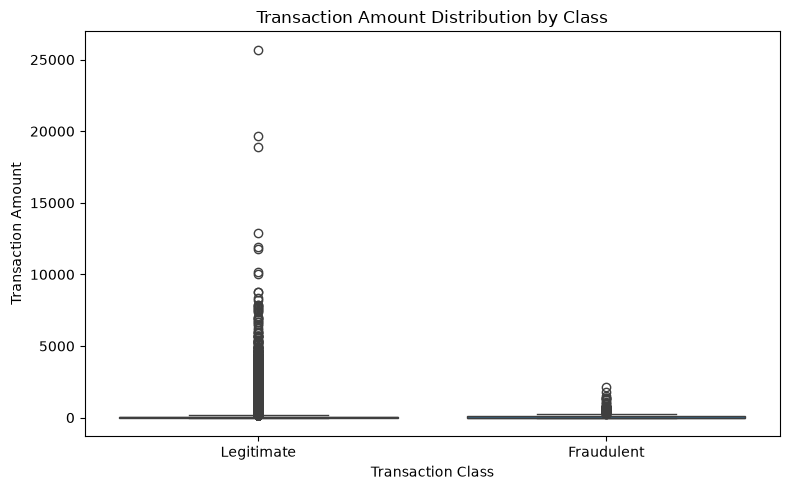

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

In [11]:
df["LogAmount"] = np.log1p(df["Amount"])

print("Log-transformed amount statistics:")
print(df.groupby("Class")["LogAmount"].describe())

Log-transformed amount statistics:
          count      mean       std  min       25%       50%      75%  \
Class                                                                   
0      284315.0  3.152762  1.655468  0.0  1.894617  3.135494  4.35735   
1         492.0  2.820596  2.214342  0.0  0.693147  2.327270  4.67180   

             max  
Class             
0      10.153941  
1       7.662407  


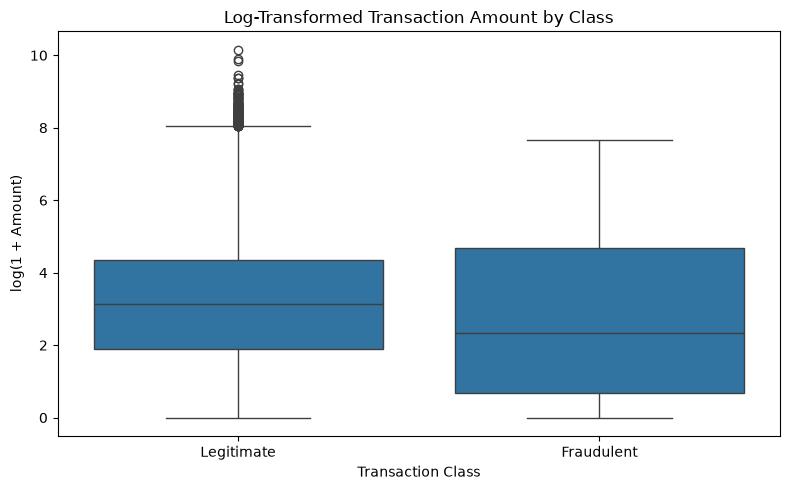

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="LogAmount"
)

plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("log(1 + Amount)")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

In [13]:
# Convert Time from seconds to hours
df["Time_hours"] = df["Time"] / 3600

print("Time range:")
print(f"Minimum: {df['Time_hours'].min():.2f} hours")
print(f"Maximum: {df['Time_hours'].max():.2f} hours")

Time range:
Minimum: 0.00 hours
Maximum: 48.00 hours


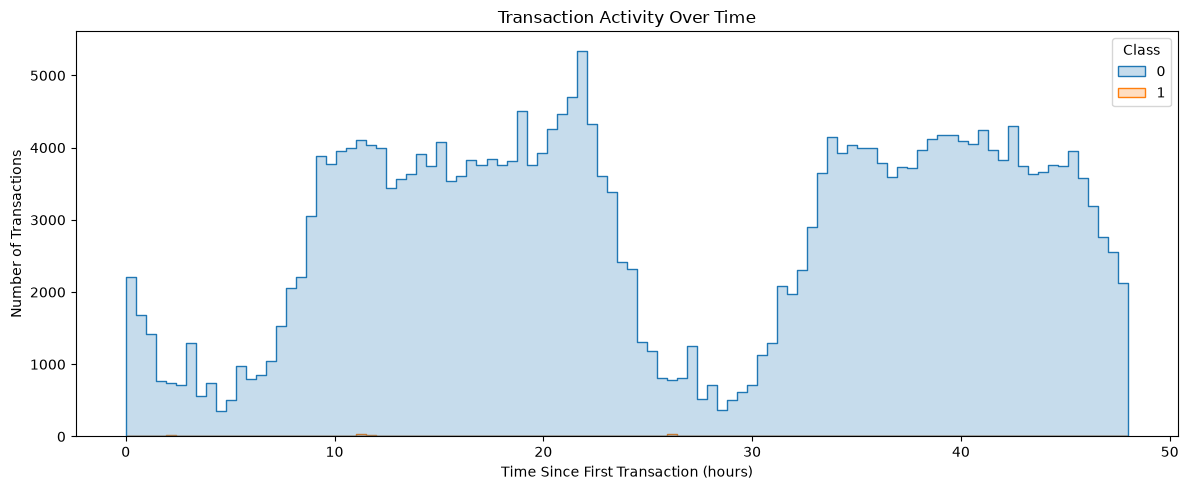

In [14]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time_hours",
    hue="Class",
    bins=100,
    element="step",
    stat="count",
    common_norm=False
)

plt.title("Transaction Activity Over Time")
plt.xlabel("Time Since First Transaction (hours)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [15]:
# Compare feature means between legitimate and fraudulent transactions

feature_cols = [col for col in df.columns if col.startswith("V")]

class_means = df.groupby("Class")[feature_cols].mean().T

class_means.columns = ["Legitimate", "Fraudulent"]

class_means["Absolute Difference"] = (
    class_means["Fraudulent"] - class_means["Legitimate"]
).abs()

class_means_sorted = class_means.sort_values(
    "Absolute Difference",
    ascending=False
)

class_means_sorted.head(10)

,Legitimate,Fraudulent,Absolute Difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


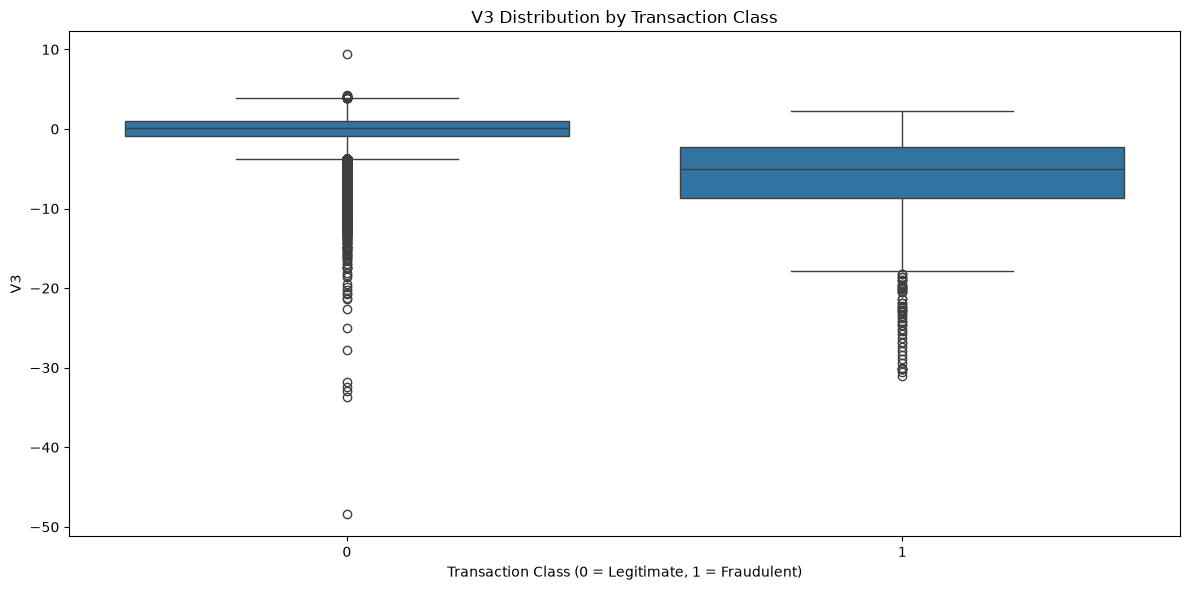

In [16]:
# Visualize the strongest features by fraud class

top_features = class_means_sorted.head(6).index.tolist()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Class",
    y=top_features[0]
)

plt.title(f"{top_features[0]} Distribution by Transaction Class")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel(top_features[0])

plt.tight_layout()
plt.show()

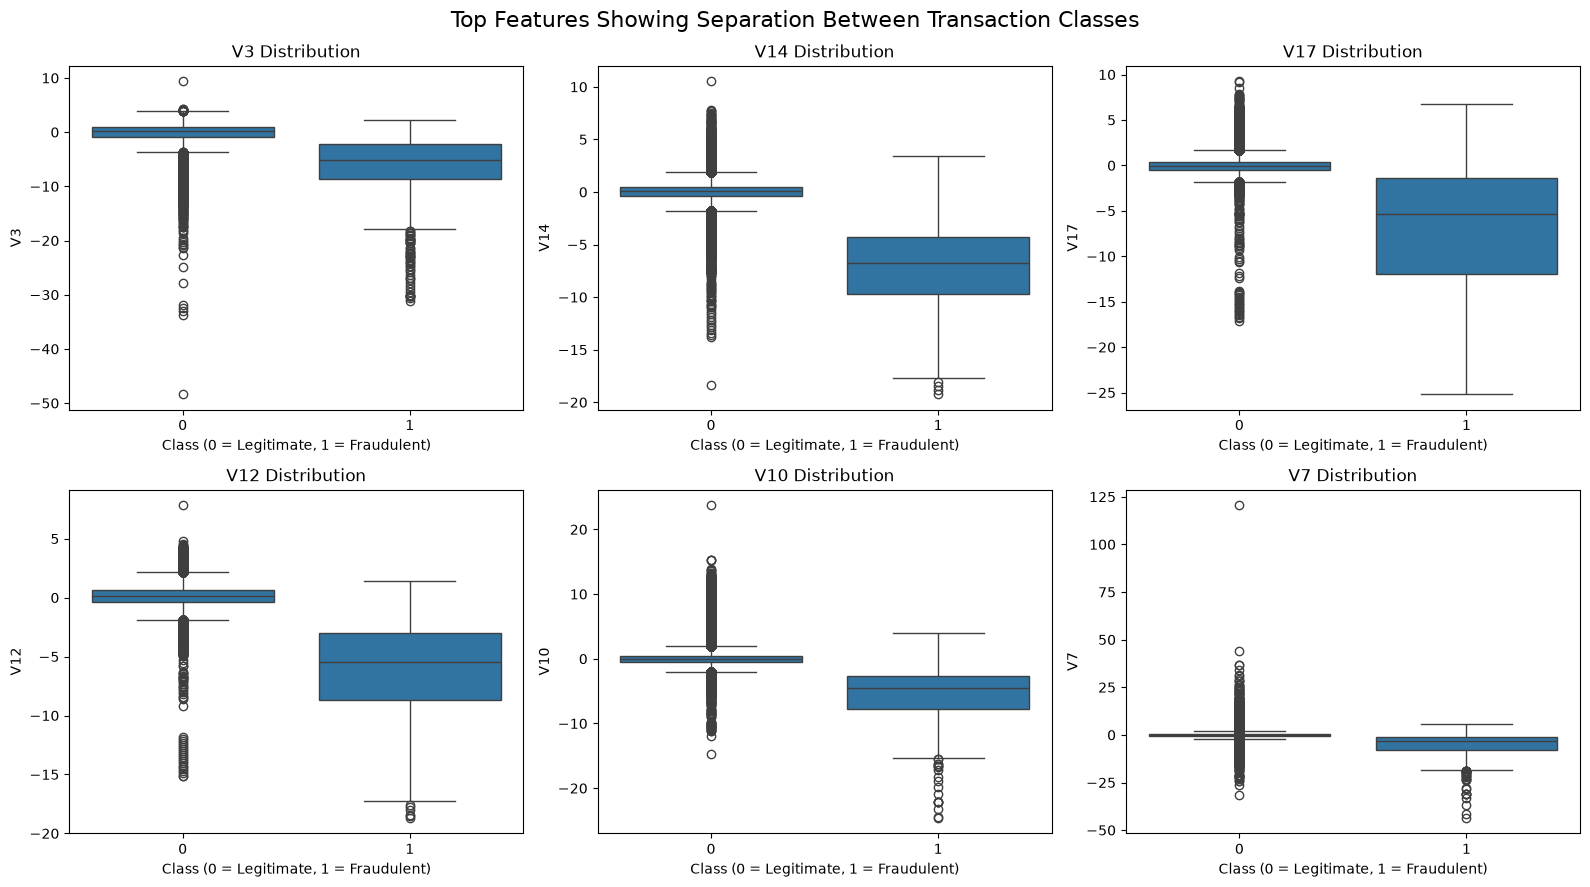

In [17]:
# Compare the six strongest features across transaction classes

top_features = class_means_sorted.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.flat, top_features):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel("Class (0 = Legitimate, 1 = Fraudulent)")
    ax.set_ylabel(feature)

plt.suptitle(
    "Top Features Showing Separation Between Transaction Classes",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [18]:
# Correlation of numerical features with fraud class

correlation_with_class = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

print("Most negative correlations with fraud:")
display(correlation_with_class.head(10))

print("\nMost positive correlations with fraud:")
display(correlation_with_class.tail(10))

Most negative correlations with fraud:


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64


Most positive correlations with fraud:


Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Name: Class, dtype: float64

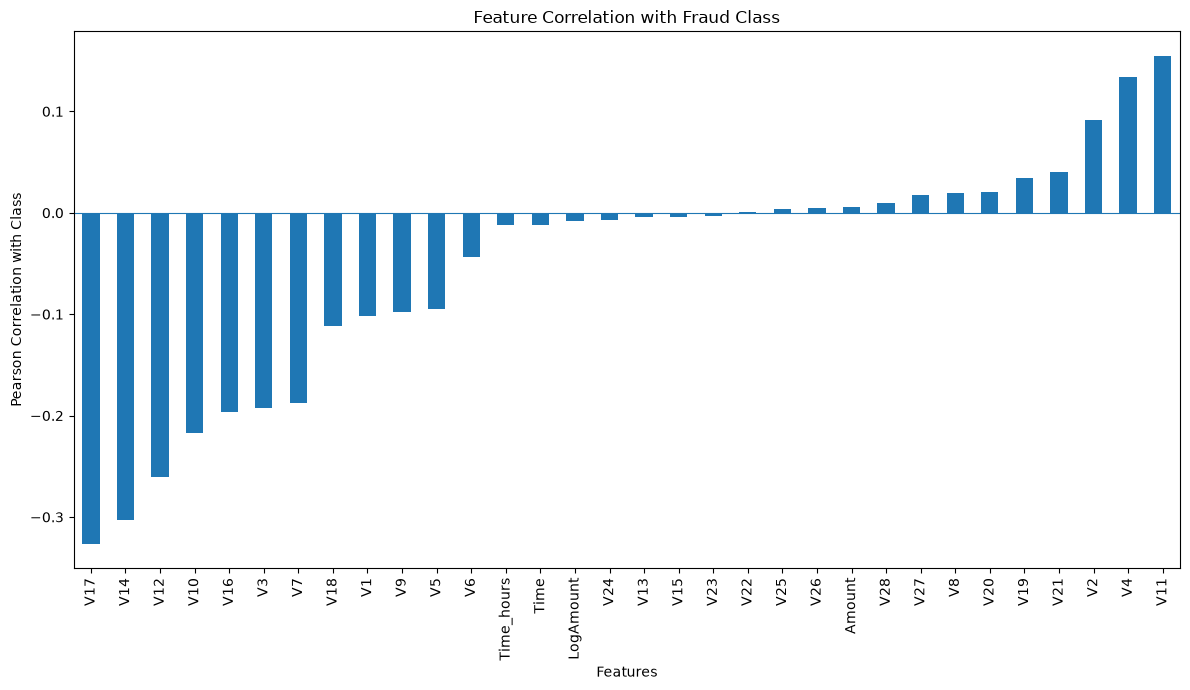

In [19]:
# Visualize feature correlation with fraud

correlation_sorted = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

plt.figure(figsize=(12, 7))

correlation_sorted.plot(kind="bar")

plt.axhline(0, linewidth=0.8)

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Features")
plt.ylabel("Pearson Correlation with Class")

plt.tight_layout()
plt.show()

In [20]:
# Quick check of full feature/target shapes before dedup (diagnostic only —
# the modeling split is built later in section 7.2 using the deduplicated data)
print("Feature matrix shape:", df.drop("Class", axis=1).shape)
print("Target distribution:\n", df["Class"].value_counts())

Feature matrix shape: (284807, 32)
Target distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


## 7. Data Preprocessing

The cleaned dataset is prepared for machine learning while preserving the integrity of the test set.

The preprocessing stage includes:
- Separating predictor variables and the target
- Stratified train-test splitting
- Feature scaling where appropriate
- Handling the severe class imbalance
- Preparing separate pipelines for supervised and anomaly-detection models

All transformations that learn parameters from the data are fitted only on the training set to prevent data leakage.

### 7.1 Feature Selection and Transformation

The original `Time` and `Amount` variables are represented using engineered transformations.

- `Time` is represented as `Time_hours` to improve interpretability.
- `Amount` is represented as `LogAmount` to reduce the effect of extreme right-skewness.
- The PCA-derived features `V1`–`V28` are retained.

The original representations are excluded to avoid redundant feature representations.

In [21]:
# Select features for supervised machine learning

feature_columns = (
    ["Time_hours"] +
    [f"V{i}" for i in range(1, 29)] +
    ["LogAmount"]
)

X_model = df_model[feature_columns]
y_model = df_model["Class"]

print("Final feature count:", X_model.shape[1])
print("\nSelected features:")
print(X_model.columns.tolist())

print("\nTarget distribution:")
print(y_model.value_counts())

NameError: name 'df_model' is not defined

### 7.2 Final Train-Test Split

The cleaned and transformed feature set is divided into training and testing subsets using a stratified split.

Stratification is essential because fraudulent transactions represent only a very small fraction of the dataset. It ensures that the class distribution remains approximately consistent across both subsets.

In [ ]:
# Final train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    stratify=y_model,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining fraud rate:", f"{y_train.mean() * 100:.4f}%")
print("Testing fraud rate:", f"{y_test.mean() * 100:.4f}%")

### 7.3 Feature Scaling

Feature scaling is applied to the predictors used by Logistic Regression because optimization of the model coefficients is sensitive to differences in feature magnitude.

A StandardScaler is fitted exclusively on the training data and then applied to both training and testing data. This prevents information from the test set from influencing the preprocessing stage.

Tree-based models such as Random Forest do not require feature scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the fitted scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Original training shape:", X_train.shape)
print("Scaled training shape:", X_train_scaled.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Scaled testing shape:", X_test_scaled.shape)

## 8. Model Development

Three complementary approaches are investigated:

1. **Logistic Regression** — an interpretable linear classification baseline.
2. **Random Forest** — a nonlinear ensemble model capable of capturing feature interactions.
3. **Isolation Forest** — an unsupervised anomaly-detection approach.

The models will be evaluated using metrics appropriate for highly imbalanced fraud detection.

### 8.1 Logistic Regression Baseline

A standard Logistic Regression model is first trained without class weighting. This establishes a baseline against which subsequent imbalance-aware approaches can be compared.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Baseline Logistic Regression
logistic_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_baseline.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression trained successfully.")

### 8.2 Baseline Predictions

The trained Logistic Regression model is used to generate both class predictions and fraud probabilities on the test set.

The probability estimates will later allow us to study classification thresholds and transaction-level risk.

In [ ]:
# Generate predictions from the baseline model

y_pred_baseline = logistic_baseline.predict(X_test_scaled)
y_prob_baseline = logistic_baseline.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(y_pred_baseline).value_counts())

print("\nFirst 10 fraud probabilities:")
print(y_prob_baseline[:10])

### 8.3 Baseline Model Evaluation

The baseline classifier is evaluated using the confusion matrix, precision, recall, F1-score, ROC-AUC, and Precision-Recall AUC.

Because fraud is extremely rare, accuracy is not used as the primary performance measure. Recall is particularly important because false negatives represent fraudulent transactions that remain undetected.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print("Confusion Matrix:")
print(cm_baseline)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

# ROC-AUC
roc_auc_baseline = roc_auc_score(
    y_test,
    y_prob_baseline
)

# PR-AUC
pr_auc_baseline = average_precision_score(
    y_test,
    y_prob_baseline
)

print(f"ROC-AUC: {roc_auc_baseline:.4f}")
print(f"PR-AUC:  {pr_auc_baseline:.4f}")

### 8.4 Class-Weighted Logistic Regression

The baseline model treats both classes equally during optimization. Because fraudulent transactions are severely underrepresented, this can result in insufficient attention to the minority class.

A class-weighted Logistic Regression model is therefore trained using balanced class weights. This increases the penalty associated with misclassifying fraudulent transactions without artificially generating new observations.

The model is evaluated on the same untouched test set used for the baseline, allowing a direct comparison of performance.

In [ ]:
# Class-weighted Logistic Regression

logistic_weighted = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_weighted.fit(X_train_scaled, y_train)

print("Class-weighted Logistic Regression trained successfully.")

### 8.5 Class-Weighted Model Predictions

The class-weighted Logistic Regression model generates fraud classifications and probability estimates on the untouched test set.

The same evaluation data and metrics used for the baseline are retained to ensure a fair comparison.

In [ ]:
# Generate predictions from the class-weighted model

y_pred_weighted = logistic_weighted.predict(X_test_scaled)
y_prob_weighted = logistic_weighted.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(y_pred_weighted).value_counts())

print("\nFirst 10 fraud probabilities:")
print(y_prob_weighted[:10])

### 8.6 Class-Weighted Model Evaluation

The class-weighted model is evaluated using the same metrics as the baseline model.

Particular attention is given to fraud-class precision, recall, F1-score, ROC-AUC, and PR-AUC. The comparison will reveal whether the increased emphasis on the minority class improves fraud detection sufficiently to justify the additional false positives.

In [ ]:
# Evaluate class-weighted Logistic Regression

cm_weighted = confusion_matrix(y_test, y_pred_weighted)

print("Confusion Matrix:")
print(cm_weighted)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

# ROC-AUC
roc_auc_weighted = roc_auc_score(
    y_test,
    y_prob_weighted
)

# PR-AUC
pr_auc_weighted = average_precision_score(
    y_test,
    y_prob_weighted
)

print(f"ROC-AUC: {roc_auc_weighted:.4f}")
print(f"PR-AUC:  {pr_auc_weighted:.4f}")

### 8.7 Classification Threshold Analysis

A probability threshold of 0.5 is commonly used for binary classification, but it is not necessarily optimal for highly imbalanced fraud detection.

An initial threshold analysis is performed to understand the relationship between the classification threshold, precision, recall, and F1-score.

This analysis is treated as a model-development diagnostic. Final threshold selection is performed separately using validation data so that the test set remains unseen during model selection.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate baseline model across multiple probability thresholds

thresholds = np.arange(0.05, 0.56, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_baseline >= threshold).astype(int)
    
    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results)

### 8.8 Precision-Recall Trade-off Across Classification Thresholds

The precision-recall trade-off is visualized across different probability thresholds.

Lower thresholds generally increase fraud detection sensitivity at the expense of additional false positives.

This development-stage analysis provides insight into the operating characteristics of the classifier. The final production threshold is selected using validation data rather than the test set.

In [ ]:
# Plot precision, recall and F1 across thresholds

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1-score"
)

# Highlight the best F1 threshold
best_threshold = threshold_results.loc[
    threshold_results["F1"].idxmax(),
    "Threshold"
]

best_f1 = threshold_results["F1"].max()

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_threshold:.2f}"
)

plt.title("Precision-Recall Trade-off Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")

### 9. Random Forest Classifier

Random Forest is introduced as a nonlinear ensemble learning method to determine whether it can improve fraud detection performance over Logistic Regression.

The model combines multiple decision trees and aggregates their predictions, allowing it to capture nonlinear relationships and interactions among transaction features.

The Random Forest model will be evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC, and confusion matrix.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully.")

In [ ]:
# Generate Random Forest predictions

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(y_pred_rf).value_counts())

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Legitimate", "Fraudulent"],
        digits=4
    )
)

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# PR-AUC
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"PR-AUC:  {pr_auc_rf:.4f}")

### 9.1 Random Forest Classification Threshold Analysis

The Random Forest probability threshold is varied to examine how the operating point affects fraud detection performance.

Precision, recall, and F1-score are analyzed to understand the trade-off between missed fraud and false alerts.

This analysis is used for model characterization. Final threshold selection is performed later using a dedicated validation set.

In [ ]:
# Evaluate Random Forest across multiple probability thresholds

rf_thresholds = np.arange(0.10, 0.56, 0.05)

rf_threshold_results = []

for threshold in rf_thresholds:
    y_pred_threshold_rf = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold_rf,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold_rf,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold_rf,
        zero_division=0
    )

    rf_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

rf_threshold_results = pd.DataFrame(rf_threshold_results)

display(rf_threshold_results)

### 9.2 Random Forest Precision-Recall Threshold Trade-off

The relationship between classification threshold, precision, recall, and F1-score is visualized to characterize the Random Forest's operating behavior.

The results provide an initial understanding of suitable operating regions, while the final classification threshold is selected using validation data.

In [ ]:
# Plot Random Forest threshold performance

plt.figure(figsize=(10, 6))

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    rf_threshold_results["Threshold"],
    rf_threshold_results["F1"],
    marker="o",
    label="F1-score"
)

# Best F1 threshold
best_rf_threshold = rf_threshold_results.loc[
    rf_threshold_results["F1"].idxmax(),
    "Threshold"
]

best_rf_f1 = rf_threshold_results["F1"].max()

plt.axvline(
    best_rf_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_rf_threshold:.2f}"
)

plt.title("Random Forest Precision-Recall Trade-off")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Random Forest threshold: {best_rf_threshold:.2f}")
print(f"Best Random Forest F1-score: {best_rf_f1:.4f}")

### 10. Isolation Forest Anomaly Detection

Isolation Forest is introduced as an unsupervised anomaly detection method.

Unlike supervised models, Isolation Forest does not use the transaction fraud labels during training. Instead, it identifies observations that are structurally unusual within the feature space.

This provides a complementary perspective to supervised fraud classification and is particularly relevant for detecting potentially novel or previously unseen fraudulent behavior.

In [ ]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest using only the training features
isolation_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(X_train_scaled)

print("Isolation Forest trained successfully.")

In [ ]:
# Generate Isolation Forest predictions

if_predictions = isolation_model.predict(X_test_scaled)

# Isolation Forest output:
#  1  -> normal transaction
# -1  -> anomaly

# Convert to fraud classification format:
#  0 -> legitimate
#  1 -> fraudulent
if_pred_class = np.where(if_predictions == -1, 1, 0)

print("Isolation Forest predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(if_pred_class).value_counts())

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Confusion Matrix
cm_if = confusion_matrix(y_test, if_pred_class)

print("Isolation Forest Confusion Matrix:")
print(cm_if)

print("\nIsolation Forest Classification Report:")
print(classification_report(
    y_test,
    if_pred_class,
    target_names=["Legitimate", "Fraudulent"]
))

In [ ]:
# Generate continuous anomaly scores
# Higher score = more anomalous
if_scores = -isolation_model.decision_function(X_test_scaled)

roc_auc_if = roc_auc_score(y_test, if_scores)
pr_auc_if = average_precision_score(y_test, if_scores)

print(f"Isolation Forest ROC-AUC: {roc_auc_if:.4f}")
print(f"Isolation Forest PR-AUC:  {pr_auc_if:.4f}")

In [ ]:
        # Final model comparison (uses actual computed metrics, not hardcoded values)

precision_if = precision_score(y_test, if_pred_class, zero_division=0)
recall_if = recall_score(y_test, if_pred_class, zero_division=0)
f1_if = f1_score(y_test, if_pred_class, zero_division=0)

comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Class-Weighted Logistic Regression",
        "Random Forest",
        "Isolation Forest"
    ],
    "ROC-AUC": [
        roc_auc_baseline,
        roc_auc_weighted,
        roc_auc_rf,
        roc_auc_if
    ],
    "PR-AUC": [
        pr_auc_baseline,
        pr_auc_weighted,
        pr_auc_rf,
        pr_auc_if
    ],
    "Fraud Precision": [
        precision_score(y_test, y_pred_baseline, zero_division=0),
        precision_score(y_test, y_pred_weighted, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_if
    ],
    "Fraud Recall": [
        recall_score(y_test, y_pred_baseline, zero_division=0),
        recall_score(y_test, y_pred_weighted, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_if
    ],
    "Fraud F1": [
        f1_score(y_test, y_pred_baseline, zero_division=0),
        f1_score(y_test, y_pred_weighted, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_if
    ]
})

comparison

In [ ]:
# Visual comparison of model performance

comparison_plot = comparison.set_index("Model")[
    ["ROC-AUC", "PR-AUC", "Fraud Precision", "Fraud Recall", "Fraud F1"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Fraud Detection Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [ ]:
# Generate fraud probability scores using the Random Forest

rf_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest fraud probabilities generated successfully.")

print("\nProbability statistics:")
print(pd.Series(rf_probabilities).describe())

In [ ]:
# Analyze fraud rate across Random Forest probability bands

risk_analysis = pd.DataFrame({
    "Fraud_Probability": rf_probabilities,
    "Actual_Fraud": y_test.values
})

risk_analysis["Probability_Band"] = pd.cut(
    risk_analysis["Fraud_Probability"],
    bins=[-0.001, 0.01, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.00],
    labels=[
        "0–1%",
        "1–5%",
        "5–10%",
        "10–20%",
        "20–35%",
        "35–50%",
        "50–75%",
        "75–100%"
    ]
)

risk_summary = risk_analysis.groupby(
    "Probability_Band",
    observed=False
).agg(
    Transactions=("Actual_Fraud", "count"),
    Fraud_Cases=("Actual_Fraud", "sum"),
    Fraud_Rate=("Actual_Fraud", "mean")
)

risk_summary["Fraud_Rate"] *= 100

risk_summary

In [ ]:
# Assign transaction risk levels based on Random Forest fraud probability

risk_analysis["Risk_Level"] = pd.cut(
    risk_analysis["Fraud_Probability"],
    bins=[-0.001, 0.01, 0.10, 0.35, 1.00],
    labels=["Low", "Moderate", "High", "Critical"]
)

print("Risk levels assigned successfully.")

print("\nRisk level distribution:")
print(risk_analysis["Risk_Level"].value_counts().sort_index())

In [ ]:
# Calculate fraud rate within each risk level

risk_level_summary = risk_analysis.groupby(
    "Risk_Level",
    observed=False
).agg(
    Transactions=("Actual_Fraud", "count"),
    Fraud_Cases=("Actual_Fraud", "sum"),
    Fraud_Rate=("Actual_Fraud", "mean")
)

risk_level_summary["Fraud_Rate"] *= 100

risk_level_summary

## 11. Model Interpretability: Feature Importance

Random Forest provides feature importance scores that indicate how strongly
each feature contributes to the model's decision-making process.

Analyzing feature importance helps identify the variables that are most
useful for distinguishing fraudulent transactions from legitimate ones.

In [ ]:
# Define the final features used by the model

selected_features = [
    'Time_hours',
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
    'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
    'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25',
    'V26', 'V27', 'V28',
    'LogAmount'
]

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

In [ ]:
# Extract Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Most Important Features:")
display(feature_importance.head(15))

In [ ]:
# Visualize top 15 feature importances

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Contributing to Fraud Detection")

plt.tight_layout()
plt.show()

## 12. Threshold-Independent Model Evaluation

Because fraudulent transactions represent only a small fraction of the dataset,
accuracy alone is not sufficient for evaluating fraud detection performance.

ROC-AUC measures the ability of a model to distinguish fraudulent transactions
from legitimate transactions across different classification thresholds.

Precision-Recall AUC is particularly important for this highly imbalanced dataset
because it focuses on the trade-off between identifying fraudulent transactions
and generating false alarms.

Therefore, ROC and Precision-Recall curves are compared across the evaluated models.

In [ ]:
# Generate prediction scores for all models

# Baseline Logistic Regression
lr_prob = logistic_baseline.predict_proba(X_test_scaled)[:, 1]

# Class-Weighted Logistic Regression
weighted_lr_prob = logistic_weighted.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Isolation Forest
# Higher value = more anomalous
if_scores = -isolation_model.decision_function(X_test_scaled)

print("Prediction scores generated successfully.")

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_wlr, tpr_wlr, _ = roc_curve(y_test, weighted_lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)


plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Baseline LR (AUC = {roc_auc_score(y_test, lr_prob):.4f})"
)

plt.plot(
    fpr_wlr,
    tpr_wlr,
    label=f"Weighted LR (AUC = {roc_auc_score(y_test, weighted_lr_prob):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})"
)

plt.plot(
    fpr_if,
    tpr_if,
    label=f"Isolation Forest (AUC = {roc_auc_score(y_test, if_scores):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Fraud Detection Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_prob)
precision_wlr, recall_wlr, _ = precision_recall_curve(y_test, weighted_lr_prob)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_prob)
precision_if, recall_if, _ = precision_recall_curve(y_test, if_scores)


plt.figure(figsize=(10, 7))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Baseline LR (PR-AUC = {average_precision_score(y_test, lr_prob):.4f})"
)

plt.plot(
    recall_wlr,
    precision_wlr,
    label=f"Weighted LR (PR-AUC = {average_precision_score(y_test, weighted_lr_prob):.4f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (PR-AUC = {average_precision_score(y_test, rf_prob):.4f})"
)

plt.plot(
    recall_if,
    precision_if,
    label=f"Isolation Forest (PR-AUC = {average_precision_score(y_test, if_scores):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison of Fraud Detection Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Validation-Based Final Random Forest Evaluation

The default classification threshold of 0.50 is not necessarily optimal for
fraud detection.

To avoid using the test set for threshold selection, the Random Forest
classification threshold is optimized using a dedicated validation set.

The threshold that maximizes the F1-score on the validation data is selected
and then frozen before evaluating the model on the unseen test set.

The final Random Forest is subsequently retrained using the complete training
dataset and evaluated once on the untouched test set.

## 13.1 Validation Set Creation

The original training set is divided into training and validation subsets.

The validation set is used exclusively for:
- Random Forest model selection
- Classification threshold optimization

The test set remains completely untouched until final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the original training data into training and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training subset shape:", X_train_final.shape)
print("Validation set shape:", X_val.shape)

print("\nTraining subset class distribution:")
print(y_train_final.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTraining subset fraud rate:",
      f"{y_train_final.mean() * 100:.4f}%")

print("Validation fraud rate:",
      f"{y_val.mean() * 100:.4f}%")

## 13.2 Random Forest Training on the Training Subset

A class-weighted Random Forest is trained using only the training subset.

The validation set is not used during model fitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_validation = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_validation.fit(X_train_final, y_train_final)

print("Random Forest validation model trained successfully.")

## 13.3 Validation Fraud Probabilities

Fraud probabilities are generated for the validation set.

These probabilities will be used to determine the optimal classification threshold.

In [ ]:
# Generate fraud probabilities on validation data
rf_val_prob = rf_validation.predict_proba(X_val)[:, 1]

print("Validation probabilities generated successfully.")

print("\nProbability statistics:")
print(pd.Series(rf_val_prob).describe())

## 13.4 Validation-Based Threshold Optimization

The classification threshold is optimized using only the validation set.

The F1-score is used as the primary optimization criterion because fraud detection requires a balance between:
- Precision — minimizing false fraud alerts
- Recall — detecting fraudulent transactions

The test set remains untouched.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.56, 0.05)

threshold_results = []

for threshold in thresholds:
    
    val_pred = (rf_val_prob >= threshold).astype(int)
    
    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

In [ ]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_rf_threshold = best_threshold_row["Threshold"]
best_rf_val_f1 = best_threshold_row["F1"]

print(f"Best validation threshold: {best_rf_threshold:.2f}")
print(f"Best validation F1-score: {best_rf_val_f1:.4f}")

print("\nBest validation performance:")
print(best_threshold_row)

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    best_rf_threshold,
    linestyle="--",
    label=f"Best threshold = {best_rf_threshold:.2f}"
)

plt.title("Random Forest Validation Threshold Optimization")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13.5 Threshold Selection and Freezing

The optimal Random Forest classification threshold is selected exclusively
using validation data (see printed output above for the exact value and
its validation F1-score).

This threshold is now frozen and will not be modified based on test-set results.

In [ ]:
FINAL_RF_THRESHOLD = best_rf_threshold

print(f"Final frozen Random Forest threshold: {FINAL_RF_THRESHOLD:.2f}")

## 13.6 Final Random Forest Training

After selecting and freezing the classification threshold using validation
data, the Random Forest is retrained using the complete training dataset.

The test set remains completely unseen during this process.

In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_scaled, y_train)

print("Final Random Forest trained successfully.")
print("Training samples used:", X_train_scaled.shape[0])

## 13.7 Final Test Prediction

The final Random Forest generates fraud probabilities for the completely
unseen test set.

The previously frozen validation threshold is applied without modification.

In [ ]:
# Generate fraud probabilities for the unseen test set
rf_final_test_prob = rf_final.predict_proba(X_test_scaled)[:, 1]

# Apply the frozen validation threshold
rf_final_test_pred = (
    rf_final_test_prob >= FINAL_RF_THRESHOLD
).astype(int)

print("Final Random Forest test predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(rf_final_test_pred).value_counts())

print(f"\nThreshold used: {FINAL_RF_THRESHOLD:.2f}")

## 13.8 Final Unseen-Test Evaluation

The finalized Random Forest is evaluated on the previously untouched test set
using the frozen validation-derived threshold.

This provides an unbiased estimate of the model's generalization performance.

The evaluation focuses on fraud-class precision, recall, F1-score, ROC-AUC,
PR-AUC, and the confusion matrix.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Confusion matrix
cm_final = confusion_matrix(y_test, rf_final_test_pred)

print("Final Random Forest Confusion Matrix:")
print(cm_final)

print("\nFinal Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_final_test_pred,
        target_names=["Legitimate", "Fraudulent"],
        digits=4
    )
)

# ROC-AUC
final_roc_auc = roc_auc_score(
    y_test,
    rf_final_test_prob
)

# PR-AUC
final_pr_auc = average_precision_score(
    y_test,
    rf_final_test_prob
)

print(f"Final Random Forest ROC-AUC: {final_roc_auc:.4f}")
print(f"Final Random Forest PR-AUC:  {final_pr_auc:.4f}")

## 14. Error Analysis

Model-level metrics summarize overall performance, but they do not explain how and where a fraud detection model makes mistakes.

Error analysis is therefore performed on the final Random Forest predictions to investigate:

- **False Positives (FP):** legitimate transactions incorrectly classified as fraudulent
- **False Negatives (FN):** fraudulent transactions incorrectly classified as legitimate
- **True Positives (TP):** fraudulent transactions correctly detected
- **True Negatives (TN):** legitimate transactions correctly classified

Particular attention is given to false negatives because undetected fraudulent transactions represent the most important failure mode in a fraud detection system.

The analysis also examines model probability scores and transaction characteristics to understand the confidence and behavior of the final classifier.

In [ ]:
# Identify prediction outcomes

error_analysis_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_final_test_pred,
    "Fraud_Probability": rf_final_test_prob
})

# Assign outcome labels
error_analysis_df["Outcome"] = "TN"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 0) &
    (error_analysis_df["Predicted"] == 1),
    "Outcome"
] = "FP"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 0),
    "Outcome"
] = "FN"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 1),
    "Outcome"
] = "TP"

print("Prediction outcome distribution:")
print(error_analysis_df["Outcome"].value_counts())

print("\nOutcome percentages:")
print(
    error_analysis_df["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

### 14.1 False Positive and False Negative Analysis

False positives and false negatives represent different operational risks in a fraud detection system.

False positives correspond to legitimate transactions that are incorrectly flagged as fraudulent, potentially causing unnecessary customer friction or manual investigation.

False negatives correspond to fraudulent transactions that are incorrectly classified as legitimate. These cases are particularly important because the fraudulent activity remains undetected.

The following analysis isolates both error groups and examines their model confidence.

In [ ]:
# Extract false positives and false negatives

false_positives = error_analysis_df[
    (error_analysis_df["Actual"] == 0) &
    (error_analysis_df["Predicted"] == 1)
]

false_negatives = error_analysis_df[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 0)
]

true_positives = error_analysis_df[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 1)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))
print("True Positives:", len(true_positives))

print("\nFalse Positive probabilities:")
print(false_positives["Fraud_Probability"].describe())

print("\nFalse Negative probabilities:")
print(false_negatives["Fraud_Probability"].describe())

print("\nTrue Positive probabilities:")
print(true_positives["Fraud_Probability"].describe())

### 14.2 Model Confidence Across Prediction Outcomes

The distribution of fraud probabilities is examined across true positives,
false positives, false negatives, and true negatives.

This analysis helps determine whether classification errors occur primarily
near the decision threshold or whether the model makes highly confident
misclassifications.

In [ ]:
# Compare fraud probability distributions by prediction outcome

plt.figure(figsize=(10, 6))

for outcome in ["TN", "FP", "FN", "TP"]:
    values = error_analysis_df.loc[
        error_analysis_df["Outcome"] == outcome,
        "Fraud_Probability"
    ]
    
    plt.hist(
        values,
        bins=20,
        alpha=0.6,
        label=outcome
    )

plt.axvline(
    FINAL_RF_THRESHOLD,
    linestyle="--",
    label=f"Decision Threshold = {FINAL_RF_THRESHOLD:.2f}"
)

plt.title("Fraud Probability Distribution by Prediction Outcome")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 14.3 Analysis of Misclassified Transactions

The misclassified transactions are isolated for detailed analysis.

Since false negatives represent fraudulent transactions that were not detected,
they are examined separately from false positives. The fraud probability and
transaction characteristics of these cases are analyzed to identify patterns
that may explain the model's errors.

In [ ]:
# Combine misclassified cases

misclassified = error_analysis_df[
    error_analysis_df["Outcome"].isin(["FP", "FN"])
].copy()

print("Total misclassified transactions:", len(misclassified))

print("\nMisclassified transaction breakdown:")
print(misclassified["Outcome"].value_counts())

print("\nMisclassified transaction probabilities:")
print(
    misclassified[
        ["Outcome", "Actual", "Predicted", "Fraud_Probability"]
    ].sort_values("Fraud_Probability", ascending=False)
)

### 14.4 Transaction Amount Analysis of Misclassified Cases

Transaction amount is examined for the misclassified transactions to determine
whether false positives and false negatives exhibit different transaction
value patterns.

The analysis uses the log-transformed transaction amount (`LogAmount`) because
the original transaction amount is highly right-skewed.

In [ ]:
# Extract LogAmount for the misclassified transactions
misclassified_amount = X_test.iloc[misclassified.index]["LogAmount"].values

misclassified["LogAmount"] = misclassified_amount

print("False Positive LogAmount statistics:")
print(
    misclassified.loc[
        misclassified["Outcome"] == "FP",
        "LogAmount"
    ].describe()
)

print("\nFalse Negative LogAmount statistics:")
print(
    misclassified.loc[
        misclassified["Outcome"] == "FN",
        "LogAmount"
    ].describe()
)

print("\nMisclassified transactions:")
print(
    misclassified[
        ["Outcome", "Fraud_Probability", "LogAmount"]
    ].sort_values("Fraud_Probability", ascending=False)
)

### 14.5 Feature-Level Analysis of False Negatives

False negatives are the most important error category in fraud detection because they represent fraudulent transactions that remain undetected.

The feature values of the false-negative transactions are compared with the overall fraudulent transactions to identify whether the missed cases exhibit unusual or less distinguishable feature patterns.

This analysis helps assess whether the final Random Forest struggles with specific regions of the feature space and provides insight into potential limitations of the available transaction features.

In [ ]:
# Align test-set features with the prediction results

error_analysis_df = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": rf_final_test_pred,
    "Fraud_Probability": rf_final_test_prob
}, index=X_test.index)

# Recreate prediction outcome labels
error_analysis_df["Outcome"] = "TN"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 0) &
    (error_analysis_df["Predicted"] == 1),
    "Outcome"
] = "FP"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 0),
    "Outcome"
] = "FN"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 1),
    "Outcome"
] = "TP"

# Extract false-negative transactions
fn_indices = error_analysis_df.index[
    error_analysis_df["Outcome"] == "FN"
]

X_fn = X_test.loc[fn_indices]
y_fn = y_test.loc[fn_indices]

print("False-negative feature matrix shape:", X_fn.shape)

print("\nFalse-negative feature means:")
print(X_fn.mean().sort_values())

print("\nOverall fraudulent transaction feature means:")
print(X_test.loc[y_test == 1].mean().sort_values())

### 14.6 False-Negative Feature Comparison

The mean values of the most influential fraud-related features are compared
between all fraudulent transactions and the false-negative subset.

The comparison focuses on the features identified earlier as having strong
relationships with the fraud target and high importance in the Random Forest.

In [ ]:
# Compare key features between all fraud cases and false negatives

key_features = [
    "V14", "V17", "V3", "V12",
    "V10", "V7", "V1", "V4"
]

comparison = pd.DataFrame({
    "All Fraud": X_test.loc[y_test == 1, key_features].mean(),
    "False Negatives": X_fn[key_features].mean()
})

comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Key Feature Comparison: All Fraud vs False Negatives")
plt.xlabel("Feature")
plt.ylabel("Mean Feature Value")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 14.7 Practical Interpretation of Fraud Detection Errors

The final Random Forest model provides a practical balance between detecting fraudulent transactions and limiting false alarms.

At the selected decision threshold, the model identifies most fraudulent transactions while generating only a small number of false positives. However, the remaining false negatives demonstrate that some fraudulent transactions have feature patterns that are difficult to distinguish from legitimate transactions.

Therefore, the model should be interpreted as a risk-screening system rather than an absolute fraud adjudication mechanism. High-risk transactions can be prioritized for further investigation, while threshold selection can be adjusted according to the operational cost of false positives versus false negatives.

## 15.1 Key Findings

The analysis produced several important findings from the financial fraud detection pipeline.

- The dataset exhibits severe class imbalance, with fraudulent transactions representing only a small fraction of the total transactions.
- Duplicate removal reduced the dataset while preserving the underlying class distribution.
- Feature preprocessing and transformation produced a final modeling dataset containing 30 selected features.
- Logistic Regression provided a strong baseline, while class weighting substantially improved fraud recall at the cost of precision.
- Random Forest provided the strongest overall fraud-detection performance among the evaluated models, particularly in terms of PR-AUC and fraud F1-score.
- Threshold optimization demonstrated that the default classification threshold is not necessarily optimal for an imbalanced fraud detection problem.
- The selected Random Forest threshold provides a practical balance between fraud recall and false-positive control.
- Isolation Forest demonstrated useful anomaly-detection capability but performed substantially worse than the supervised Random Forest model for this labeled dataset.
- Feature-importance analysis identified V14, V10, V12, V17, and V4 among the most influential features for the Random Forest model.
- Transaction-level risk analysis showed a strong concentration of observed fraud cases within the highest-risk probability bands.
- Error analysis demonstrated that false negatives can occur even when transactions exhibit some characteristics associated with legitimate transactions.

## 15.2 Model Selection Rationale

Random Forest was selected as the final fraud detection model because it provided the most favorable balance between fraud precision, recall, F1-score, and PR-AUC among the evaluated approaches.

The final model achieved:

- **Fraud Precision:** 0.9333
- **Fraud Recall:** 0.7368
- **Fraud F1-score:** 0.8235
- **PR-AUC:** 0.8011
- **ROC-AUC:** 0.9391
- **Selected Decision Threshold:** 0.40

Threshold optimization further demonstrated that the operating point can be adjusted according to the desired balance between missed fraud cases and false alarms.

Therefore, the final system uses Random Forest as the primary supervised detection model and treats the classification threshold as an operational decision parameter rather than a fixed default.

## 15.3 Limitations

Despite the strong predictive performance of the final Random Forest model, several limitations should be considered.

- The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.
- The available `V1–V28` variables are anonymized principal components, which limits direct business interpretation of the underlying transaction characteristics.
- The dataset represents a specific historical transaction environment; therefore, model performance may not generalize directly to other financial institutions, transaction systems, or future fraud patterns.
- The final model still produces false negatives, meaning that some fraudulent transactions remain undetected.
- Threshold selection involves a trade-off between fraud recall and false-positive rate. A threshold that is appropriate for one operational environment may not be optimal for another.
- The analysis evaluates predictive performance on a held-out test set, but real-world deployment would require continuous monitoring for concept drift and changes in fraud behavior.
- The risk scores generated by the Random Forest should be interpreted as relative model scores rather than guaranteed probabilities of fraud.

## 15.4 Future Improvements

The fraud detection system can be extended in several directions.

- **Cost-sensitive learning:** Incorporate explicit business costs for false positives and false negatives when selecting the operating threshold.
- **Advanced ensemble methods:** Evaluate gradient boosting approaches such as XGBoost, LightGBM, or CatBoost for potentially improved discrimination.
- **Temporal analysis:** Incorporate transaction velocity, spending patterns, and sequential transaction behavior when historical transaction sequences are available.
- **Model explainability:** Apply SHAP or similar explainability techniques to provide transaction-level explanations for high-risk predictions.
- **Real-time deployment:** Develop an inference pipeline capable of assigning risk scores to transactions as they occur.
- **Concept-drift monitoring:** Continuously monitor model performance and feature distributions to detect changes in fraud behavior.
- **Human-in-the-loop investigation:** Use risk scores to prioritize transactions for manual review rather than treating model predictions as final fraud decisions.
- **Threshold recalibration:** Periodically reassess the operating threshold as the relative costs of missed fraud and false alarms change.

## 15.5 Conclusion

This project developed an end-to-end financial fraud detection and transaction risk analytics pipeline for a highly imbalanced classification problem.

The analysis progressed from data quality assessment and exploratory analysis through feature engineering, preprocessing, supervised learning, anomaly detection, threshold optimization, risk scoring, and error analysis.

Among the evaluated approaches, the Random Forest model provided the strongest overall balance for the final supervised fraud detection system. At the selected operating threshold, it achieved high fraud precision while detecting a substantial proportion of fraudulent transactions and generating only a small number of false positives.

The analysis also demonstrated that model evaluation for fraud detection cannot rely on accuracy alone. Precision, recall, F1-score, ROC-AUC, PR-AUC, and the operational consequences of false positives and false negatives provide a more informative assessment.

Finally, the risk-scoring analysis demonstrates how a predictive model can move beyond binary classification toward transaction-level prioritization. In a practical financial environment, such a system can support fraud analysts by ranking transactions according to risk and directing investigative resources toward the highest-risk cases.

Overall, the project demonstrates the complete analytical workflow required to develop, evaluate, interpret, and operationalize a machine-learning-based fraud detection system.